In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

In [ ]:
steps_low = c(0.01, 0.1)
steps_mid = c(0.1, 0.5)
steps_high = c(0.5, 1)
novelties = c(0.5, 0.95, 1.25)
communities = paste0('marine', seq(0, length(novelties) - 1), "novelty", novelties)
d1 = data.table(expand.grid(community = communities, ts = steps_low, tg = steps_low, 
                            tf = steps_low,
                            to = steps_mid, tc = steps_high, tp = steps_high,
                            td = steps_high, tr = steps_high,
                            mask = seq(0, 4)))
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    to_read = paste0('output_singlem_dev/opal/tune_s', ts, 'g', tg, 'f', tf, 'o', to, 'c', tc,
                     'p', tp, 'd', td, 'r', tr, 'mask', mask, '/', community,'.opal_report')
    if (!file.exists(to_read)) return()
    return(fread(to_read))
}
d2 = d1[, readit(community, ts, tg, tf, to, tc, tp, td, tr, mask),
        by=list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]

In [3]:
#d2 = data.table(community = communities[1], ts = 0.1, tg = 0,
#                tf = 0, to = 0, tc = 0, tp = 0, td = 0, tr = 0,
#                mask = 0)[, readit(community, ts, tg, tf, to, tc, tp, td, tr, mask),
#                          by = list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]
d2[1:5,]

community,ts,tg,tf,to,tc,tp,td,tr,mask,tool,rank,metric,sample,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,Gold standard,kingdom,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,Gold standard,phylum,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,Gold standard,class,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,Gold standard,order,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,Gold standard,family,Bray-Curtis distance,SAMPLEID,0


In [4]:
s1 = d2[tool != "Gold standard" & metric == "Bray-Curtis distance"]
s1[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]
setnames(s1, "value", "Bray-Curtis distance")

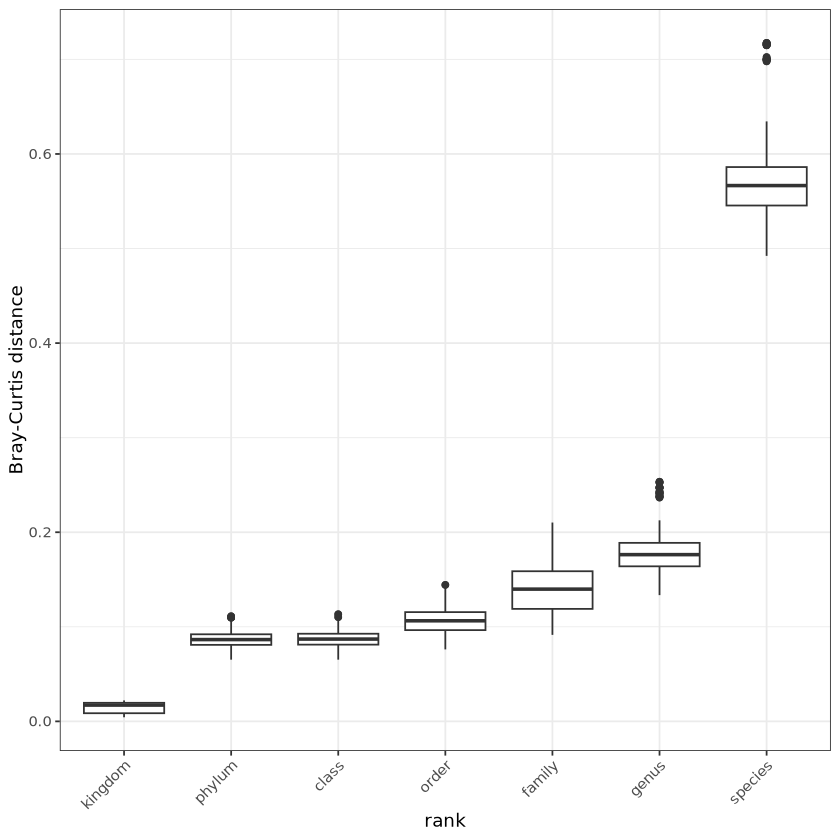

In [5]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1, aes(rank, `Bray-Curtis distance`)) +
   geom_boxplot() +
   scale_x_discrete(na.translate = FALSE) +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position=c(0.1,0.4)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3))

# NMF penalty tuning

In [ ]:
readloss = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    to_read = paste0('output_singlem_dev/singlem_dev/tune_s', ts, 'g', tg, 'f', tf, 'o', to, 'c', tc,
                     'p', tp, 'd', td, 'r', tr, 'mask', mask, '/', community,'.loss.tsv')
    if (!file.exists(to_read)) return()
    return(fread(to_read, header = FALSE, col.names = c("metric", "value")))
}
d2 = d1[, readloss(community, ts, tg, tf, to, tc, tp, td, tr, mask),
        by=list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]

In [7]:
#d2 = data.table(community = communities[1], ts = 0.1, tg = 0,
#                tf = 0, to = 0, tc = 0, tp = 0, td = 0, tr = 0,
#                mask = 0)[, readloss(community, ts, tg, tf, to, tc, tp, td, tr, mask),
#                          by = list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]
d2[1:5,]

community,ts,tg,tf,to,tc,tp,td,tr,mask,metric,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF loss,67.078
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF mask loss,108.263
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF penalised loss,97.488
marine0novelty0.5,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF steps,5001.000
marine2novelty1.25,0.01,0.01,0.01,0.1,0.5,0.5,0.5,0.5,0,NMF loss,78.279


In [8]:
d2_steps = d2[metric == "NMF steps"]
d2_steps[, metric := NULL]
setnames(d2_steps, "value", "steps")
d3 = d2[!metric %in% c("NMF steps", "NMF penalised loss"), ][d2_steps, on = .NATURAL]

In [14]:
s1 = d3[
    ,
    list(value = sum(value), steps = max(steps)),
    by = list(community, ts, tg, tf, to, tc, tp, td, tr, metric)
]
s1[metric == "NMF loss", value := value / 4]
tunecols = c("ts", "tg", "tf", "to", "tc", "tp", "td", "tr")
for (i in seq(2, length(tunecols))) {
    s1[[tunecols[i]]] = s1[[tunecols[i]]] + s1[[tunecols[i-1]]]
}
s1[1:10,]

community,ts,tg,tf,to,tc,tp,td,tr,metric,value,steps
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
marine0novelty0.5,0.01,0.02,0.03,0.13,0.63,1.13,1.63,2.13,NMF loss,82.93525,5001
marine0novelty0.5,0.01,0.02,0.03,0.13,0.63,1.13,1.63,2.13,NMF mask loss,523.62300,5001
marine2novelty1.25,0.01,0.02,0.03,0.13,0.63,1.13,1.63,2.13,NMF loss,73.25375,2185
marine2novelty1.25,0.01,0.02,0.03,0.13,0.63,1.13,1.63,2.13,NMF mask loss,399.44000,2185
marine0novelty0.5,0.10,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF loss,83.15275,5001
marine0novelty0.5,0.10,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF mask loss,519.84300,5001
marine2novelty1.25,0.10,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF loss,57.53550,1658
marine2novelty1.25,0.10,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF mask loss,295.39000,1658
marine0novelty0.5,0.01,0.11,0.12,0.22,0.72,1.22,1.72,2.22,NMF loss,84.17325,1896


In [16]:
plot_rank <- function(data, rank) {
    other_ranks <- setdiff(c("ts", "tg", "tf", "to", "tp", "td", "tr"), rank)
    data[["group"]] <- interaction(data[, other_ranks, with = FALSE])
    ggplot(data, aes(.data[[rank]], value, colour = metric,
                     alpha = steps > 5000,
                     group = interaction(group, metric))) +
   geom_point() +
   geom_line() +
   facet_wrap(vars(community)) +
   theme(legend.title=element_blank()) +
   #theme(legend.position=c(0.1,0.4)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3))
}

Warning message:
“Using alpha for a discrete variable is not advised.”


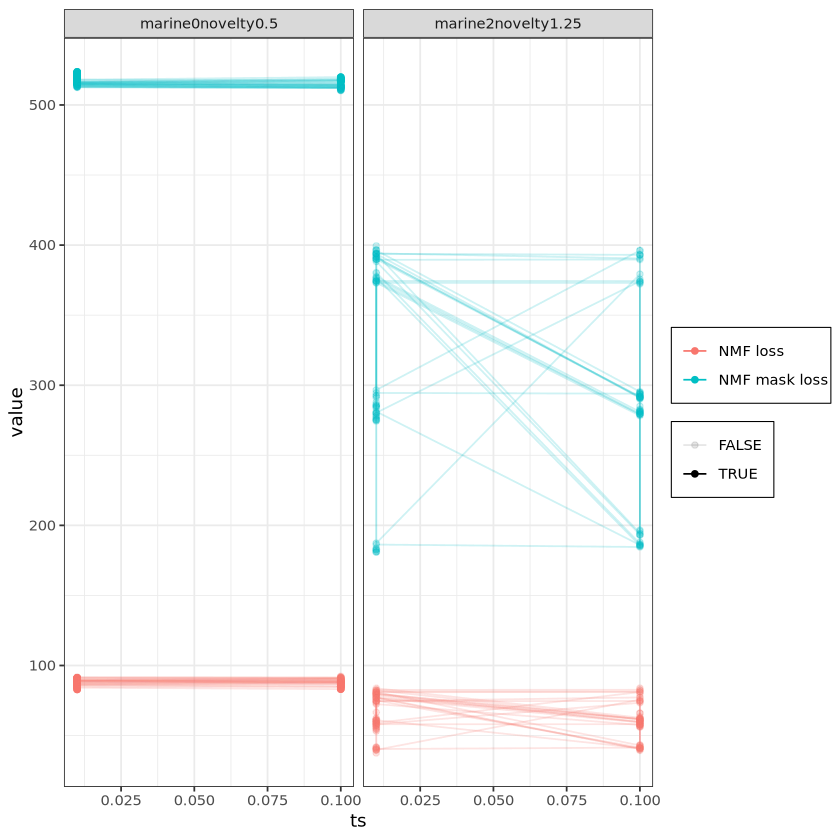

In [17]:
plot_rank(s1, "ts")